# 02 — Exploratory Data Analysis (EDA)

## Rossmann Sales Forecasting — Project 6

**Objective:** Explore sales behaviour across time, promotions, holidays, customers, store characteristics, and competition-related variables to identify business patterns and modelling implications.

This notebook follows the official Project 6 EDA requirements. The analysis uses descriptive statistics and visualizations; observed relationships are not interpreted as causal effects unless explicitly supported.

### EDA flow
1. Load and validate data
2. Create calendar features and merge store information
3. Perform data-quality checks
4. Analyse sales, customers, promotions and holidays
5. Analyse weekday/weekend, assortment and competition behaviour
6. Compare train/test distributions
7. Visualize key findings
8. Summarize business insights and modelling implications

## 1. Data Loading & Initial Setup
Load the local Rossmann train, store and test datasets. The relative paths are used so the notebook can run from the project `notebooks/` folder.


In [1]:
import pandas as pd

train = pd.read_csv('../train.csv')
store = pd.read_csv('../store.csv')

print("Train dataset shape:", train.shape)
print("Store dataset shape:", store.shape)

C:\Users\satish\AppData\Local\Temp\ipykernel_23008\656881227.py:3: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('../train.csv')


Train dataset shape: (1017209, 15)
Store dataset shape: (1115, 10)


In [2]:
train['Date'] = pd.to_datetime(train['Date'])

print(train['Date'].dtype)
print(train['Date'].min())
print(train['Date'].max())

datetime64[us]
2013-01-01 00:00:00
2015-07-31 00:00:00


In [3]:
train['Year'] = train['Date'].dt.year

print(train[['Date', 'Year']].head())

        Date  Year
0 2015-07-31  2015
1 2015-07-31  2015
2 2015-07-31  2015
3 2015-07-31  2015
4 2015-07-31  2015


In [4]:
train['Month'] = train['Date'].dt.month
train['Day'] = train['Date'].dt.day
train['WeekOfYear'] = train['Date'].dt.isocalendar().week.astype(int)

print(train[['Date', 'Year', 'Month', 'Day', 'WeekOfYear']].head())

        Date  Year  Month  Day  WeekOfYear
0 2015-07-31  2015      7   31          31
1 2015-07-31  2015      7   31          31
2 2015-07-31  2015      7   31          31
3 2015-07-31  2015      7   31          31
4 2015-07-31  2015      7   31          31


In [5]:
train['IsWeekend'] = train['DayOfWeek'].isin([6, 7]).astype(int)

print(train[['DayOfWeek', 'IsWeekend']].drop_duplicates().sort_values('DayOfWeek'))

      DayOfWeek  IsWeekend
4460          1          0
3345          2          0
2230          3          0
1115          4          0
0             5          0
6690          6          1
5575          7          1


In [6]:
train['YearMonth'] = train['Date'].dt.to_period('M').astype(str)

print(train[['Date', 'YearMonth']].head())

        Date YearMonth
0 2015-07-31   2015-07
1 2015-07-31   2015-07
2 2015-07-31   2015-07
3 2015-07-31   2015-07
4 2015-07-31   2015-07


In [7]:
merged = train.merge(
    store,
    on='Store',
    how='left'
)

print("Merged dataset shape:", merged.shape)
print("\nMerged columns:")
print(merged.columns.tolist())

Merged dataset shape: (1017209, 24)

Merged columns:
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend', 'YearMonth', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


## 2. Data Quality & Cleaning Assessment
First inspect missing values, structural missingness, duplicates and mixed data types. Missing values are assessed here but are not blindly imputed during EDA. The machine-learning pipeline handles applicable numerical/categorical missing values later.


In [8]:
missing_values = merged.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing_values)

Columns with missing values:
Promo2SinceYear              508031
Promo2SinceWeek              508031
PromoInterval                508031
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
CompetitionDistance            2642
dtype: int64


In [9]:
promo2_check = merged.groupby('Promo2')[[
    'Promo2SinceWeek',
    'Promo2SinceYear',
    'PromoInterval'
]].apply(lambda x: x.isnull().sum())

print(promo2_check)

        Promo2SinceWeek  Promo2SinceYear  PromoInterval
Promo2                                                 
0                508031           508031         508031
1                     0                0              0


In [10]:
competition_missing = merged[
    ['CompetitionOpenSinceMonth',
     'CompetitionOpenSinceYear',
     'CompetitionDistance']
].isnull().sum()

print("Competition-related missing values:")
print(competition_missing)

Competition-related missing values:
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
CompetitionDistance            2642
dtype: int64


In [11]:
duplicate_count = merged.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [12]:
merged['StateHoliday'] = merged['StateHoliday'].astype(str)

print(merged['StateHoliday'].map(type).value_counts())
print("\nStateHoliday values:")
print(merged['StateHoliday'].value_counts())

StateHoliday
<class 'str'>    1017209
Name: count, dtype: int64

StateHoliday values:
StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64


### StateHoliday standardization decision
`StateHoliday` originally contains mixed representations of zero (`0` and `'0'`). Standardizing it to string prevents duplicate categories during grouping and ensures consistent downstream processing.


## 3. Sales & Customer Behaviour
Establish target distribution, zero-sales behaviour and the relationship between Sales and Customers.


In [13]:
print("Sales statistics:")
print(merged['Sales'].describe())

print("\nCustomers statistics:")
print(merged['Customers'].describe())

Sales statistics:
count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

Customers statistics:
count    1.017209e+06
mean     6.331459e+02
std      4.644117e+02
min      0.000000e+00
25%      4.050000e+02
50%      6.090000e+02
75%      8.370000e+02
max      7.388000e+03
Name: Customers, dtype: float64


In [14]:
print("Sales = 0 and Store Open = 0:",
      ((merged['Sales'] == 0) & (merged['Open'] == 0)).sum())

print("Sales = 0 and Store Open = 1:",
      ((merged['Sales'] == 0) & (merged['Open'] == 1)).sum())

print("\nCustomers = 0 and Store Open = 0:",
      ((merged['Customers'] == 0) & (merged['Open'] == 0)).sum())

print("Customers = 0 and Store Open = 1:",
      ((merged['Customers'] == 0) & (merged['Open'] == 1)).sum())

Sales = 0 and Store Open = 0: 172817
Sales = 0 and Store Open = 1: 54

Customers = 0 and Store Open = 0: 172817
Customers = 0 and Store Open = 1: 52


In [15]:
print("Sales statistics:")
print(train['Sales'].describe())

print("\nNumber of zero-sales records:")
print((train['Sales'] == 0).sum())

print("\nNumber of negative-sales records:")
print((train['Sales'] < 0).sum())

Sales statistics:
count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

Number of zero-sales records:
172871

Number of negative-sales records:
0


In [16]:
print("Sales = 0 when store is closed:")
print(train.loc[train['Open'] == 0, 'Sales'].eq(0).all())

print("\nNumber of closed-store records:")
print((train['Open'] == 0).sum())

print("\nNumber of closed-store records with non-zero sales:")
print(((train['Open'] == 0) & (train['Sales'] != 0)).sum())

Sales = 0 when store is closed:
True

Number of closed-store records:
172817

Number of closed-store records with non-zero sales:
0


In [17]:
open_data = merged[merged['Open'] == 1]

print("Open-store records:", len(open_data))
print("Zero-sales records while open:", (open_data['Sales'] == 0).sum())
print("Average sales while open:", open_data['Sales'].mean())
print("Maximum sales while open:", open_data['Sales'].max())

Open-store records: 844392
Zero-sales records while open: 54
Average sales while open: 6955.514290755952
Maximum sales while open: 41551


In [18]:
sales_customers_corr = merged['Sales'].corr(merged['Customers'])

print("Correlation between Sales and Customers:",
      round(sales_customers_corr, 4))

Correlation between Sales and Customers: 0.8947


## 4. Promotion Analysis
Evaluate promotion impact descriptively and examine how consistently promotions are deployed across stores.


In [19]:
promo_analysis = merged.groupby('Promo')[['Sales', 'Customers']].mean()

print("Average Sales and Customers by Promotion:")
print(promo_analysis)

Average Sales and Customers by Promotion:
             Sales   Customers
Promo                         
0      4406.050805  517.823542
1      7991.152046  820.098815


In [20]:
promo_distribution = merged['Promo'].value_counts().sort_index()

print("Promotion distribution:")
print(promo_distribution)

print("\nPromotion percentage:")
print((merged['Promo'].value_counts(normalize=True).sort_index() * 100).round(2))

Promotion distribution:
Promo
0    629129
1    388080
Name: count, dtype: int64

Promotion percentage:
Promo
0    61.85
1    38.15
Name: proportion, dtype: float64


In [21]:
store_promo = (
    merged.groupby('Store')['Promo']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={
        'count': 'Total_Days',
        'sum': 'Promo_Days',
        'mean': 'Promo_Rate'
    })
)

store_promo['Promo_Rate'] = (store_promo['Promo_Rate'] * 100).round(2)

print("Promotion deployment across stores:")
print(store_promo.head(10))

print("\nStore promotion rate summary:")
print(store_promo['Promo_Rate'].describe())

Promotion deployment across stores:
       Total_Days  Promo_Days  Promo_Rate
Store                                    
1             942         360       38.22
2             942         360       38.22
3             942         360       38.22
4             942         360       38.22
5             942         360       38.22
6             942         360       38.22
7             942         360       38.22
8             942         360       38.22
9             942         360       38.22
10            942         360       38.22

Store promotion rate summary:
count    1115.000000
mean       38.140933
std         0.180387
min        37.730000
25%        38.220000
50%        38.220000
75%        38.220000
max        38.260000
Name: Promo_Rate, dtype: float64


## 5. Holiday & Seasonal Analysis
Analyse school holidays, state holidays, before/during/after holiday behaviour, and Christmas/Easter-related patterns.


In [22]:
school_holiday_analysis = (
    merged.groupby('SchoolHoliday')[['Sales', 'Customers']]
    .mean()
)

print("Average Sales and Customers by School Holiday:")
print(school_holiday_analysis)

Average Sales and Customers by School Holiday:
                     Sales   Customers
SchoolHoliday                         
0              5620.979034  617.645174
1              6476.522207  704.412941


In [23]:
state_holiday_analysis = (
    merged.groupby('StateHoliday')[['Sales', 'Customers']]
    .mean()
)

print("Average Sales and Customers by State Holiday:")
print(state_holiday_analysis)

Average Sales and Customers by State Holiday:
                    Sales   Customers
StateHoliday                         
0             5947.483893  651.819833
a              290.735686   43.817670
b              214.311510   36.561883
c              168.733171   27.174390


In [24]:
holiday_dates = (
    merged[merged['StateHoliday'] != '0']['Date']
    .drop_duplicates()
    .sort_values()
)

holiday_sales = []

for date in holiday_dates:
    for offset, period in [(-1, 'Before'), (0, 'During'), (1, 'After')]:
        target_date = date + pd.Timedelta(days=offset)
        
        day_data = merged[merged['Date'] == target_date]
        
        if len(day_data) > 0:
            holiday_sales.append({
                'HolidayDate': date,
                'Period': period,
                'Sales': day_data['Sales'].mean(),
                'Customers': day_data['Customers'].mean()
            })

holiday_sales_df = pd.DataFrame(holiday_sales)

print("Average Sales and Customers before, during and after State Holidays:")
print(
    holiday_sales_df.groupby('Period')[['Sales', 'Customers']]
    .mean()
    .reindex(['Before', 'During', 'After'])
)

Average Sales and Customers before, during and after State Holidays:
              Sales   Customers
Period                         
Before  5621.286362  609.393134
During  1793.176554  207.652253
After   6795.668178  746.123575


In [25]:
christmas_sales = merged[
    (merged['Date'].dt.month == 12) &
    (merged['Date'].dt.day >= 20) &
    (merged['Date'].dt.day <= 31)
].groupby(merged['Date'].dt.day)[['Sales', 'Customers']].mean()

easter_sales = merged[
    (merged['Date'].dt.month.isin([3, 4])) &
    (merged['StateHoliday'] == 'b')
].groupby('Date')[['Sales', 'Customers']].mean()

print("Christmas period - average Sales and Customers by day:")
print(christmas_sales)

print("\nEaster-related State Holiday days:")
print(easter_sales)

Christmas period - average Sales and Customers by day:
             Sales    Customers
Date                           
20     9898.003415   993.487317
21     5085.177561   533.401951
22     5498.351220   571.347317
23    12225.453659  1292.151220
24     4802.694634   526.933171
25      145.351707    23.645366
26      192.114634    30.703415
27     6770.175610   776.150732
28     3387.628780   387.023415
29     3667.306829   408.235610
30     8711.160000   950.004390
31     4112.417073   475.238537

Easter-related State Holiday days:
                 Sales  Customers
Date                             
2013-03-29  191.857399  32.085202
2013-04-01  216.211659  37.304036
2014-04-18  199.430493  34.293274
2014-04-21  216.132735  38.942601
2015-04-03  217.464574  35.417040
2015-04-06  244.772197  41.329148


## 6. Weekday, Weekend & Store Opening Behaviour


In [26]:
weekday_analysis = (
    merged.groupby('DayOfWeek')[['Sales', 'Customers', 'Open']]
    .mean()
)

print("Average Sales, Customers and Open status by Day of Week:")
print(weekday_analysis)

Average Sales, Customers and Open status by Day of Week:
                 Sales   Customers      Open
DayOfWeek                                   
1          7809.044510  813.065791  0.950459
2          7005.244467  760.984615  0.988309
3          6555.884138  721.639666  0.974400
4          6247.575913  697.541486  0.923199
5          6723.274305  743.150742  0.950598
6          5847.562599  657.112237  0.995357
7           204.183189   35.786817  0.024826


In [27]:
store_weekday_open = (
    merged.groupby(['Store', 'DayOfWeek'])['Open']
    .mean()
    .unstack()
)

all_days_open_stores = store_weekday_open[
    (store_weekday_open == 1).all(axis=1)
]

print("Number of stores open on all 7 days:",
      len(all_days_open_stores))

print("\nStores open on all 7 days:")
print(all_days_open_stores.index.tolist())

Number of stores open on all 7 days: 10

Stores open on all 7 days:
[85, 262, 335, 423, 494, 562, 682, 733, 769, 1097]


In [28]:
weekend_analysis = (
    merged.groupby('IsWeekend')[['Sales', 'Customers', 'Open']]
    .mean()
)

print("Average Sales, Customers and Open status:")
print("0 = Weekday, 1 = Weekend")
print(weekend_analysis)

Average Sales, Customers and Open status:
0 = Weekday, 1 = Weekend
                 Sales   Customers      Open
IsWeekend                                   
0          6866.806351  747.178595  0.957392
1          3025.872894  346.449527  0.510091


## 7. Store Assortment Analysis


In [29]:
assortment_analysis = (
    merged.groupby('Assortment')[['Sales', 'Customers']]
    .mean()
    .sort_values('Sales', ascending=False)
)

print("Average Sales and Customers by Store Assortment:")
print(assortment_analysis)

Average Sales and Customers by Store Assortment:
                  Sales    Customers
Assortment                          
b           8553.931999  2046.361828
c           6058.676567   624.222733
a           5481.026096   619.164636


## 8. Competition Analysis
Examine competition distance, distance bands, and availability of competition-opening information. The dataset does not provide a direct city-centre flag, so distance bands are used as a descriptive proxy rather than a city-centre classification.


In [30]:
competition_analysis = (
    merged.groupby('CompetitionDistance')['Sales']
    .mean()
)

print("Correlation between Competition Distance and Sales:",
      round(merged['CompetitionDistance'].corr(merged['Sales']), 4))

print("\nCompetition Distance statistics:")
print(merged['CompetitionDistance'].describe())

Correlation between Competition Distance and Sales: -0.0192

Competition Distance statistics:
count    1.014567e+06
mean     5.430086e+03
std      7.715324e+03
min      2.000000e+01
25%      7.100000e+02
50%      2.330000e+03
75%      6.890000e+03
max      7.586000e+04
Name: CompetitionDistance, dtype: float64


In [31]:
merged['CompetitionDistanceBand'] = pd.cut(
    merged['CompetitionDistance'],
    bins=[0, 1000, 3000, 5000, 10000, float('inf')],
    labels=[
        'Very Near (<1 km)',
        'Near (1–3 km)',
        'Medium (3–5 km)',
        'Far (5–10 km)',
        'Very Far (>10 km)'
    ]
)

distance_analysis = (
    merged.groupby('CompetitionDistanceBand', observed=True)[
        ['Sales', 'Customers']
    ].mean()
)

print("Average Sales and Customers by Competition Distance:")
print(distance_analysis)

Average Sales and Customers by Competition Distance:
                               Sales   Customers
CompetitionDistanceBand                         
Very Near (<1 km)        6063.365791  767.773880
Near (1–3 km)            5721.778293  623.243373
Medium (3–5 km)          5577.551594  580.739924
Far (5–10 km)            5567.718124  520.141578
Very Far (>10 km)        5685.546657  549.766126


In [32]:
competition_reopening = store[
    store['CompetitionDistance'].notna() &
    store['CompetitionOpenSinceYear'].isna()
][[
    'Store',
    'CompetitionDistance',
    'CompetitionOpenSinceMonth',
    'CompetitionOpenSinceYear'
]]

print("Stores with Competition Distance available but opening date missing:")
print("Number of stores:", len(competition_reopening))
print(competition_reopening.head(20))

Stores with Competition Distance available but opening date missing:
Number of stores: 351
    Store  CompetitionDistance  CompetitionOpenSinceMonth  \
11     12               1070.0                        NaN   
12     13                310.0                        NaN   
15     16               3270.0                        NaN   
18     19               3240.0                        NaN   
21     22               1040.0                        NaN   
25     26               2300.0                        NaN   
28     29               2170.0                        NaN   
31     32               2910.0                        NaN   
39     40                180.0                        NaN   
40     41               1180.0                        NaN   
41     42                290.0                        NaN   
42     43               4880.0                        NaN   
61     62               2050.0                        NaN   
63     64              22560.0                        N

In [33]:
missing_competition_distance = store[
    store['CompetitionDistance'].isna()
][[
    'Store',
    'CompetitionDistance',
    'CompetitionOpenSinceMonth',
    'CompetitionOpenSinceYear'
]]

print("Stores with missing Competition Distance:")
print("Number of stores:", len(missing_competition_distance))
print(missing_competition_distance)

Stores with missing Competition Distance:
Number of stores: 3
     Store  CompetitionDistance  CompetitionOpenSinceMonth  \
290    291                  NaN                        NaN   
621    622                  NaN                        NaN   
878    879                  NaN                        NaN   

     CompetitionOpenSinceYear  
290                       NaN  
621                       NaN  
878                       NaN  


## 9. Train vs Test Distribution Check
Compare key operational and calendar variables between the training and test datasets. Large differences are reported as distribution shifts rather than automatically treated as data errors.


In [34]:
test_eda = pd.read_csv('../test.csv')

print("Train shape:", train.shape)
print("Test shape:", test_eda.shape)

print("\nPromotion distribution - Train:")
print((train['Promo'].value_counts(normalize=True) * 100).round(2))

print("\nPromotion distribution - Test:")
print((test_eda['Promo'].value_counts(normalize=True) * 100).round(2))

Train shape: (1017209, 15)
Test shape: (41088, 8)

Promotion distribution - Train:
Promo
0    61.85
1    38.15
Name: proportion, dtype: float64

Promotion distribution - Test:
Promo
0    60.42
1    39.58
Name: proportion, dtype: float64


In [35]:
print("Open distribution - Train:")
print((train['Open'].value_counts(normalize=True) * 100).round(2))

print("\nOpen distribution - Test:")
print((test_eda['Open'].value_counts(normalize=True) * 100).round(2))

print("\nSchoolHoliday distribution - Train:")
print((train['SchoolHoliday'].value_counts(normalize=True) * 100).round(2))

print("\nSchoolHoliday distribution - Test:")
print((test_eda['SchoolHoliday'].value_counts(normalize=True) * 100).round(2))

Open distribution - Train:
Open
1    83.01
0    16.99
Name: proportion, dtype: float64

Open distribution - Test:
Open
1.0    85.43
0.0    14.57
Name: proportion, dtype: float64

SchoolHoliday distribution - Train:
SchoolHoliday
0    82.14
1    17.86
Name: proportion, dtype: float64

SchoolHoliday distribution - Test:
SchoolHoliday
0    55.65
1    44.35
Name: proportion, dtype: float64


## 10. Key EDA Visualizations
These charts provide visual evidence for the main business findings. The charts are intentionally simple and presentation-friendly.


Matplotlib is building the font cache; this may take a moment.


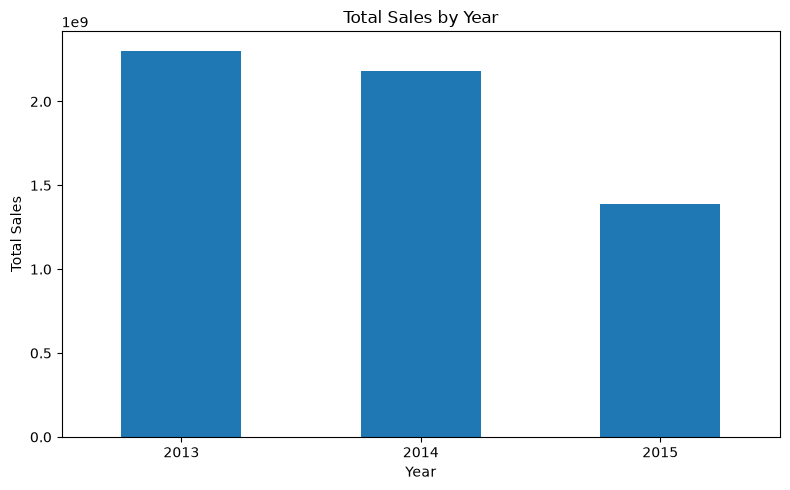

In [36]:
import matplotlib.pyplot as plt

annual_sales = (
    merged.groupby('Year')['Sales']
    .sum()
)

plt.figure(figsize=(8, 5))
annual_sales.plot(kind='bar')

plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

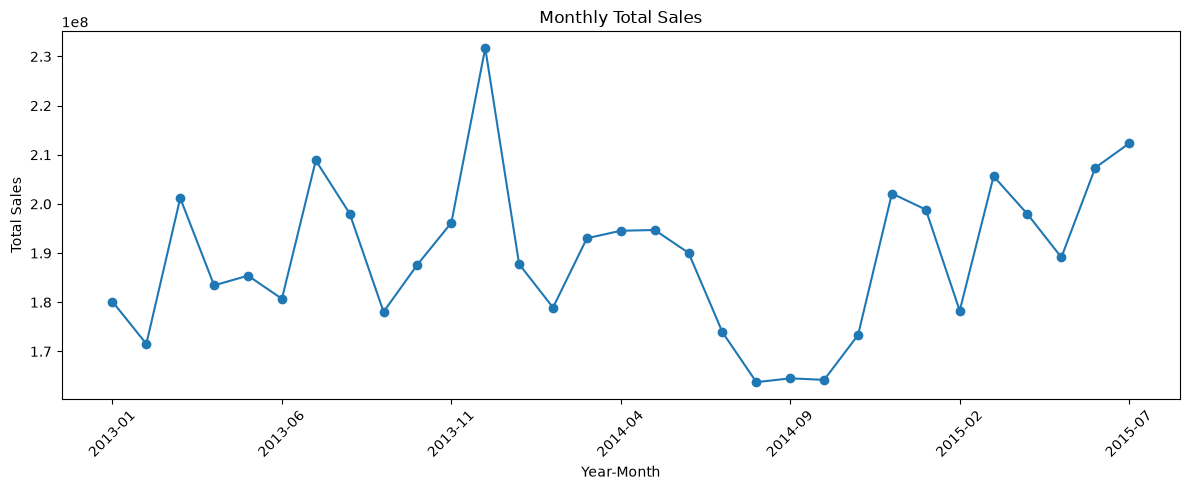

In [37]:
monthly_sales = (
    merged.groupby('YearMonth')['Sales']
    .sum()
)

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Total Sales')
plt.xlabel('Year-Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

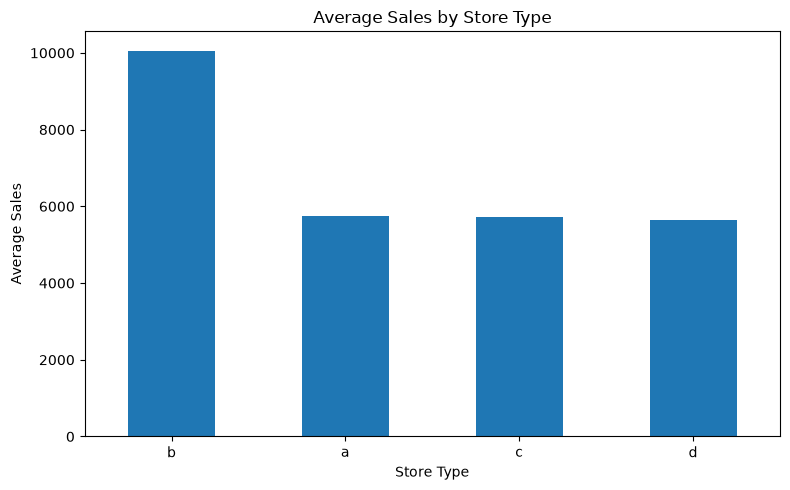

In [38]:
store_type_analysis = (
    merged.groupby('StoreType')[['Sales', 'Customers']]
    .mean()
    .sort_values('Sales', ascending=False)
)

plt.figure(figsize=(8, 5))
store_type_analysis['Sales'].plot(kind='bar')

plt.title('Average Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

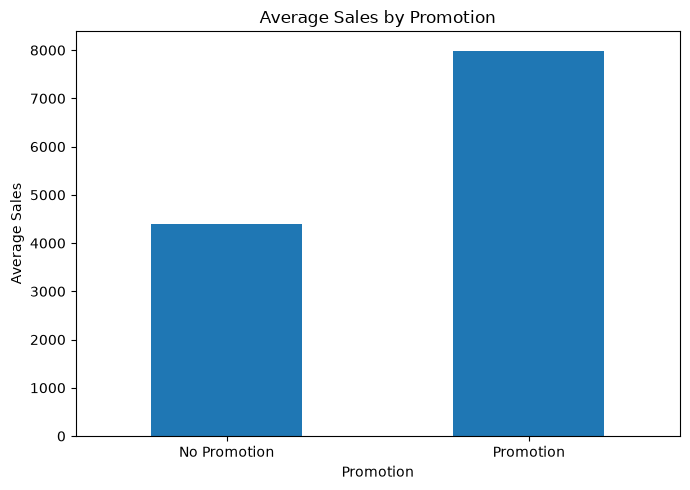

In [39]:
plt.figure(figsize=(7, 5))

promo_analysis['Sales'].plot(kind='bar')

plt.title('Average Sales by Promotion')
plt.xlabel('Promotion')
plt.ylabel('Average Sales')
plt.xticks([0, 1], ['No Promotion', 'Promotion'], rotation=0)
plt.tight_layout()
plt.show()

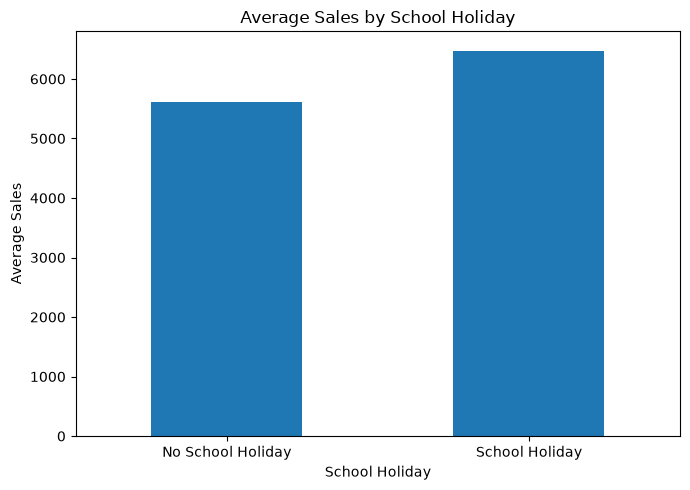

In [40]:
plt.figure(figsize=(7, 5))

school_holiday_analysis['Sales'].plot(kind='bar')

plt.title('Average Sales by School Holiday')
plt.xlabel('School Holiday')
plt.ylabel('Average Sales')
plt.xticks([0, 1], ['No School Holiday', 'School Holiday'], rotation=0)
plt.tight_layout()
plt.show()

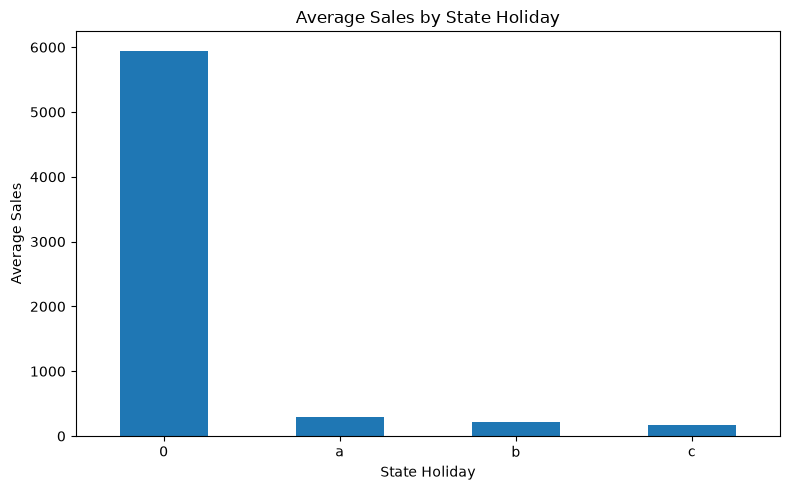

In [41]:
plt.figure(figsize=(8, 5))

state_holiday_analysis['Sales'].plot(kind='bar')

plt.title('Average Sales by State Holiday')
plt.xlabel('State Holiday')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

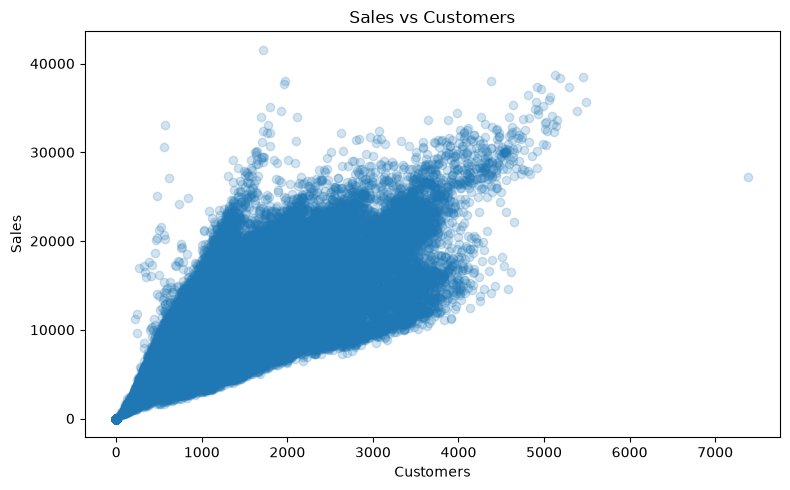

In [42]:
plt.figure(figsize=(8, 5))

plt.scatter(
    merged['Customers'],
    merged['Sales'],
    alpha=0.2
)

plt.title('Sales vs Customers')
plt.xlabel('Customers')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

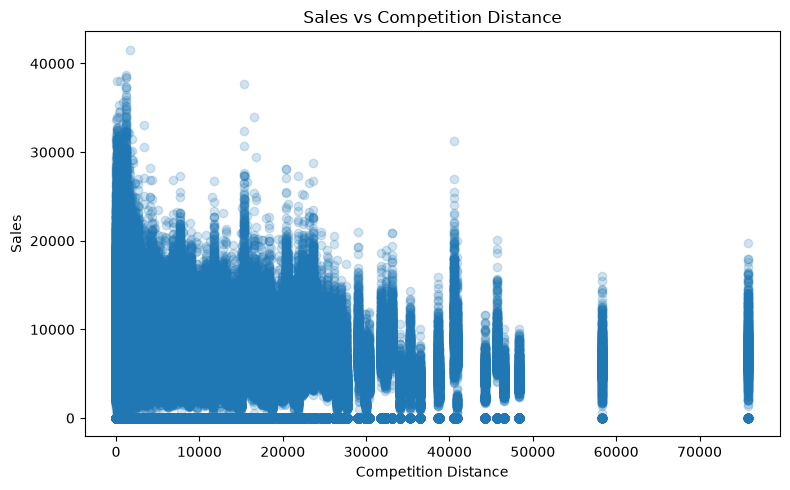

In [43]:
plt.figure(figsize=(8, 5))

plt.scatter(
    merged['CompetitionDistance'],
    merged['Sales'],
    alpha=0.2
)

plt.title('Sales vs Competition Distance')
plt.xlabel('Competition Distance')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

## 11. Business Insights & Modelling Implications

### Data quality
- The merged dataset contains **1,017,209 rows and 24 columns** with no duplicate rows.
- `Promo2SinceWeek`, `Promo2SinceYear` and `PromoInterval` are structural missing values when `Promo2 = 0`; they are retained rather than incorrectly filled.
- `CompetitionDistance` is missing for only **3 stores** in the Store master data (Stores 291, 622 and 879).
- There are **351 stores** with competition distance available but competition opening month/year unavailable.
- `StateHoliday` was standardized to string to avoid treating `0` and `'0'` as separate categories.

### Sales and customer behaviour
- Sales and Customers have a strong positive correlation of **0.8947**.
- Almost all zero Sales/Customers records occur when stores are closed: **172,817** closed-store records have zero Sales and zero Customers.
- Only **54** open-store records have zero Sales and **52** open-store records have zero Customers, so these are exceptional cases worth retaining for investigation/model robustness.

### Promotions
- Promotions appear in **38.15%** of training store-day records and **39.58%** of test records, showing a broadly similar deployment mix.
- Average Sales are approximately **7,991** during promotions versus **4,406** without promotions.
- Promotion deployment is highly consistent across stores, with an average rate of about **38.14%** and very small variation.

### Holidays and seasonality
- School-holiday records have higher average Sales and Customers than non-school-holiday records in this dataset; this is an observed association.
- State-holiday records have much lower average Sales and Customers than non-holiday records.
- Around state holidays, average Sales fall during the holiday period and rebound after the holiday.
- Christmas shows a strong seasonal pattern, including a sharp drop around **December 25** and recovery afterward.
- Easter-related StateHoliday days also show substantially reduced activity.

### Weekday/weekend and store operations
- Sunday has extremely low average Sales because only about **2.48%** of stores are open on Sunday.
- Saturday has the highest average opening rate at about **99.54%**.
- Only **10 stores** are open on all seven days in the observed training period.
- Weekday/weekend differences therefore need to be interpreted together with store operating status.

### Store characteristics
- Store Type **B** has substantially higher average Sales than Store Types A, C and D.
- Assortment **B** has the highest average Sales and Customers among the assortment groups.

### Competition
- Sales vs CompetitionDistance has a very weak linear correlation of **-0.0192**.
- Distance-band analysis does not show a monotonic relationship; the very-near group (<1 km) has the highest descriptive average Sales, but the pattern varies across bands.
- This does not mean competition distance is unimportant for machine learning: tree-based models can capture nonlinear and interaction effects that simple correlation cannot.

### Train/test distribution
- Open distribution is reasonably similar between train and test.
- Promotion distribution is also broadly similar.
- SchoolHoliday shows a substantial shift (**17.86%** in train vs **44.35%** in test), which should be treated as a calendar/time-period distribution shift rather than automatically corrected.

## 12. Modelling Handoff

The EDA indicates that Sales depend on a combination of:
- store and store-type characteristics,
- operating status,
- promotions,
- calendar/weekly seasonality,
- holidays,
- competition-related variables,
- and customer behaviour.

For forecasting, features must be available at prediction time. Therefore, **Customers should not be used as an input for the initial Sales forecasting model when future customer counts are unknown**, even though Sales and Customers are strongly correlated.

The next notebook uses preprocessing pipelines, a tree-based model and time-aware validation, followed by time-series modelling with LSTM.


### Notebook evidence note
The executed outputs from the user's latest EDA session have been retained in this organized version. Duplicate/legacy exploratory cells from the source notebook were consolidated into the main analytical flow; the original uploaded notebook remains unchanged as the source backup.
